# Import important libraries (pandas, numpy, matplotlib, seaborn, sklearn).

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

## Part 1: Data Preparation

### Load the dataset using sklearn.


In [57]:
from sklearn.datasets import load_iris


### Convert the dataset into a pandas DataFrame.


In [58]:
df = load_iris()
x = df.data

In [59]:
target = df.target
df = pd.DataFrame(x, columns=df.feature_names)
df['species'] = target
# make file in proccessed folder and save it as csv
df.to_csv("data/row/iris.csv", index=False)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Check data shape
### Inspect data types


df.shape()

In [60]:
df.shape

(150, 5)

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### View summary statistics


In [62]:
# View summary statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Check class distribution


<Axes: >

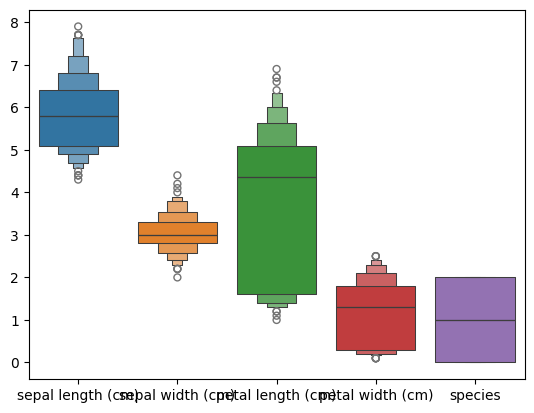

In [63]:
# Check class distribution
sns.boxenplot(data=df)

<Axes: >

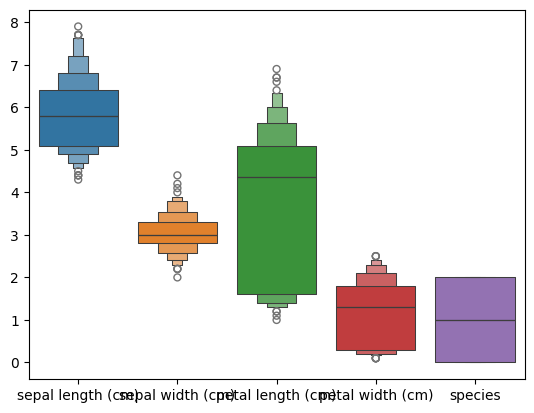

In [64]:
sns.boxenplot(data=df)

### Split the dataset into training and testing sets using train_test_split.

In [65]:
# <!-- Split the dataset into training and testing sets using train_test_split.
#  -->
x = df.drop(columns=['petal length (cm)', 'species'])
y = df['species']
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(
    x, y, test_size=0.2, random_state=42)

In [66]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Apply feature scaling using StandardScaler.


In [67]:
# Apply feature scaling using StandardScaler.
from sklearn.preprocessing import StandardScaler
# call the scaler
scaler = StandardScaler()
# use fit_transform on the training data
x_train_scaled = scaler.fit_transform(x_train)
# use transform on the testing data
x_test_scaled = scaler.transform(x_test)

## Part 2: One-vs-Rest (OVR)

### Implement Logistic Regression using the built-in OVR approach:
LogisticRegression(multi_class='ovr')
Train the model on the training data.
Make predictions on the test data.
Evaluate the model using:
Accuracy
Precision
Recall
F1-score
Display the following:
Classification report
Confusion matrix


In [68]:
# Implement Logistic Regression using the built-in OVR approach:
# LogisticRegression(multi_class='ovr')
from sklearn.linear_model import LogisticRegression
# call the model
model = LogisticRegression(multi_class='ovr', solver='liblinear')
# fit the model on the training data    
model.fit(x_train_scaled, y_train)
# predict on the testing data   
y_pred = model.predict(x_test_scaled)
# Evaluate the model using accuracy_score, classification_report, and confusion_matrix.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100, "%")
# classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)
# confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 96.66666666666667 %
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


c:\Users\LAP ME\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\LAP ME\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


###  One-vs-One (OVO)
Implement One-vs-One classification using:
OneVsOneClassifier(LogisticRegression())
Train the model on the training data.
Make predictions on the test data.
Evaluate the model using:
Accuracy
Precision
Recall
F1-score


In [69]:
#  One-vs-One (OVO)
# Implement One-vs-One classification using:
# OneVsOneClassifier(LogisticRegression())
# Train the model on the training data.
# Make predictions on the test data.
# Evaluate the model using:
# Accuracy
# Precision
# Recall
# F1-score
from sklearn.multiclass import OneVsOneClassifier
# call the model
ovo_model = OneVsOneClassifier(LogisticRegression(solver='liblinear'))
# fit the model on the training data
ovo_model.fit(x_train_scaled, y_train)
# predict on the testing data
ovo_y_pred = ovo_model.predict(x_test_scaled)
# calculate accuracy
ovo_accuracy = accuracy_score(y_test, ovo_y_pred)
print("One-vs-One Accuracy:", ovo_accuracy * 100, "%")
# classification report
ovo_report = classification_report(y_test, ovo_y_pred)
print("One-vs-One Classification Report:\n", ovo_report)
# confusion matrix

ovo_conf_matrix = confusion_matrix(y_test, ovo_y_pred)
print("One-vs-One Confusion Matrix:\n", ovo_conf_matrix)

One-vs-One Accuracy: 100.0 %
One-vs-One Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

One-vs-One Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## Part 4: Support Vector Machine (SVM)


### Train SVM models using  => Linear kernel
Evaluate each model using:
Accuracy
Precision
Recall
F1-score



In [70]:
from sklearn.svm import SVC
# call the model    
svm_model = SVC(kernel='linear')
# fit the model on the training data
svm_model.fit(x_train_scaled, y_train)
#  accuracy
svm_y_pred = svm_model.predict(x_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_y_pred)
#  recall
svm_report = classification_report(y_test, svm_y_pred)
# precision
svm_precision = svm_report.split()[-4]
# f1-score
f1_score = svm_report.split()[-2]
print("SVM Accuracy:", svm_accuracy)
print("SVM Recall:", svm_report.split()[-3])
print("SVM Precision:", svm_precision)
print("SVM F1-Score:", f1_score)


SVM Accuracy: 0.9666666666666667
SVM Recall: 0.97
SVM Precision: 0.97
SVM F1-Score: 0.97


In [71]:
svm_model = SVC(kernel='poly', degree=3)
svm_model.fit(x_train_scaled, y_train)
# accuracy
svm_y_pred_poly = svm_model.predict(x_test_scaled)

# recall
svm_report_poly = classification_report(y_test, svm_y_pred_poly)

# precision
svm_precision_poly = svm_report_poly.split()[-4]

# f1-score
f1_score_poly = svm_report_poly.split()[-2]

print("SVM with Polynomial Kernel Accuracy:", svm_accuracy)
print("SVM with Polynomial Kernel Recall:", svm_report_poly.split()[-3])
print("SVM with Polynomial Kernel Precision:", svm_precision_poly)
print("SVM with Polynomial Kernel F1-Score:", f1_score_poly)


SVM with Polynomial Kernel Accuracy: 0.9666666666666667
SVM with Polynomial Kernel Recall: 0.97
SVM with Polynomial Kernel Precision: 0.97
SVM with Polynomial Kernel F1-Score: 0.97


In [72]:
svm_model = SVC(kernel='rbf')
svm_model.fit(x_train_scaled, y_train)
# accuracy
svm_y_pred_rbf = svm_model.predict(x_test_scaled)
# recall
svm_report_rbf = classification_report(y_test, svm_y_pred_rbf)
# precision
svm_precision_rbf = svm_report_rbf.split()[-4]
# f1-score
f1_score_rbf = svm_report_rbf.split()[-2]
print("SVM with RBF Kernel Accuracy:", svm_accuracy)
print("SVM with RBF Kernel Recall:", svm_report_rbf.split()[-3])
print("SVM with RBF Kernel Precision:", svm_precision_rbf)
print("SVM with RBF Kernel F1-Score:", f1_score_rbf)

SVM with RBF Kernel Accuracy: 0.9666666666666667
SVM with RBF Kernel Recall: 1.00
SVM with RBF Kernel Precision: 1.00
SVM with RBF Kernel F1-Score: 1.00


### Compare SVM performance with Logistic Regression (OVR and OVO).

In [73]:
# Compare SVM performance with Logistic Regression (OVR and OVO).
print("Logistic Regression (OVR) Accuracy:", accuracy * 100, "%")
print("One-vs-One Logistic Regression Accuracy:", ovo_accuracy * 100, "%")

Logistic Regression (OVR) Accuracy: 96.66666666666667 %
One-vs-One Logistic Regression Accuracy: 100.0 %


In [74]:
## Select one of the following approaches to implement manually (without using sklearn wrappers): - One-vs-Rest (OVR) - One-vs-One (OVO)

In [75]:
# # Requirements: 1. Train multiple binary Logistic Regression classifiers manually. 2. Implement the prediction logic: - For OVR: choose the class with the highest probability. - For OVO: use majority voting among classifiers. 3. Compare the manual implementation results with the sklearn implementation.

# calsses 
classes = np.unique(y_train)
print("Classes:", classes)

# over models
over_models = {}
for cls in classes:
    # create binary labels for the current class
    y_binary = (y_train == cls).astype(int)
    # train a logistic regression model for the current class
    model = LogisticRegression(solver='liblinear')
    model.fit(x_train_scaled, y_binary)
    # store the model in the dictionary
    over_models[cls] = model
# make predictions using the OVR models
ovr_predictions = np.zeros((x_test_scaled.shape[0], len(classes)))
for i, cls in enumerate(classes):
    ovr_predictions[:, i] = over_models[cls].predict_proba(x_test_scaled)[:, 1]
# choose the class with the highest probability
ovr_predicted_classes = np.argmax(ovr_predictions, axis=1)  
# evaluate the OVR model
ovr_accuracy_manual = accuracy_score(y_test, ovr_predicted_classes)



Classes: [0 1 2]


In [76]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression( solver='liblinear')
sklearn_model.fit(x_train_scaled, y_train)
sklearn_pred = sklearn_model.predict(x_test_scaled)

sklearn_accuracy = accuracy_score(y_test, sklearn_pred)

print("Manual OVR Accuracy:", ovr_accuracy_manual)
print("Sklearn OVR Accuracy:", sklearn_accuracy)

Manual OVR Accuracy: 0.9666666666666667
Sklearn OVR Accuracy: 0.9666666666666667


c:\Users\LAP ME\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


### Comparison and Analysis

# OVR vs OVO (Simple Comparison)

## 1. Performance

### OVR (One-vs-Rest)
- Easy and fast to train
- Works fine for most basic problems
- Can struggle a bit if classes are not balanced

### OVO (One-vs-One)
- Usually gives better separation between classes
- Works better when classes are close to each other
- Takes more effort to train and manage

---

## 2. Accuracy

- OVR: Gives good accuracy in most cases
- OVO: Often slightly better or more stable

On simple datasets, both usually give almost the same result.

---

## 3. Precision, Recall, F1-score

### OVR
- Precision: Good, but may drop with imbalance
- Recall: Might miss some smaller classes
- F1-score: Balanced but not always the best

### OVO
- Precision: Often better
- Recall: More balanced across classes
- F1-score: Usually more consistent

---

## 4. Number of Models

### OVR
- One model per class
- If you have 3 classes → 3 models

### OVO
- One model for every pair of classes
- Formula: n(n - 1) / 2
- If you have 3 classes → 3 models
- If you have 5 classes → 10 models

---

## 5. Speed and Cost

### Training
- OVR: Faster because fewer models
- OVO: Slower because many models

### Prediction
- OVR: Faster decision
- OVO: Slower because it uses voting between models

---

## 6. When to Use

### OVR is better when:
- You want something simple
- You have large data
- You care about speed

### OVO is better when:
- You want better accuracy
- Data is not very large
- Classes are hard to separate

---

## 7. Final Idea

- OVR is simple and fast
- OVO is more detailed and often more accurate

In real projects:
- OVR is used when speed matters
- OVO is used when accuracy matters more

### Part 7: Visualization
Plot the confusion matrix for both OVR and OVO models.
(Optional) Visualize decision boundaries if applicable.


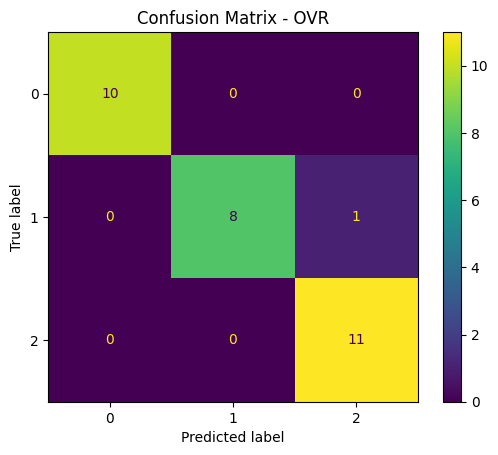

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_ovr = confusion_matrix(y_test, ovr_predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_ovr)
disp.plot()
plt.title("Confusion Matrix - OVR")
plt.show()

### Answer the following questions clearly:
Why is OVO generally slower than OVR?
Why can OVR introduce bias?
How does class imbalance affect OVR and OVO?


OVR vs OVO - Key Questions

 1. Why is OVO slower than OVR?
OVO trains one model for every pair of classes, so the number of models grows fast: n(n−1)/2.  
It also needs voting during prediction, which makes it slower than OVR.

---

2. Why can OVR introduce bias?
OVR trains each model as “one class vs all others”, which creates an imbalance.  
The “rest” group is much larger, so the model may favor dominant classes and perform worse on smaller ones.

---

3. How does class imbalance affect OVR and OVO?

- **OVR:** strongly affected  
  Minority classes may be ignored because they are compared against a large combined group.

- **OVO:** less affected  
  Each model only compares two classes, so imbalance impact is smaller.

---

 Summary
- OVO = slower but often fairer and more accurate  
- OVR = faster but can be biased with imbalanced data